# Train/Test Split Cluster Visualization
Visualize the KMeans semantic split used in `dataset.py`.
Embedding: `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`

In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from pathlib import Path

DATA_DIR = Path("../data/kuhperdata")

In [15]:
# Load queries
queries = {}
with open(DATA_DIR / "queries.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        queries[obj["_id"]] = obj["text"]

# Load split info
with open(DATA_DIR / "split_indices.json", "r", encoding="utf-8") as f:
    split = json.load(f)

with open(DATA_DIR / "dataset_stats.json", "r", encoding="utf-8") as f:
    stats = json.load(f)

train_qids = set(split["train_query_ids"])
test_qids = set(split["test_query_ids"])
train_clusters = set(stats["split_info"]["train_clusters"])
test_clusters = set(stats["split_info"]["test_clusters"])
n_clusters = stats["split_info"]["n_clusters"]

print(f"Queries: {len(queries)} (train={len(train_qids)}, test={len(test_qids)})")
print(f"Clusters: {n_clusters} (train={len(train_clusters)}, test={len(test_clusters)})")

Queries: 961 (train=749, test=212)
Clusters: 50 (train=31, test=19)


In [16]:
# Embed all queries with the same model used for splitting
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Maintain original order (q0, q1, ..., q960)
sorted_qids = sorted(queries.keys(), key=lambda x: int(x[1:]))
texts = [queries[qid] for qid in sorted_qids]

embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True)
print(f"Embeddings: {embeddings.shape}")

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Embeddings: (961, 384)


In [17]:
# Reproduce KMeans clustering (same params as dataset.py)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# Labels: train/test per query
split_labels = np.array(["train" if qid in train_qids else "test" for qid in sorted_qids])

print(f"Cluster label counts: {np.unique(cluster_labels, return_counts=True)}")

Cluster label counts: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
      dtype=int32), array([ 8, 15, 30, 16, 16, 41, 18, 39, 24, 18,  2, 18, 17,  5,  6,  3, 33,
        9, 20, 19, 29, 40, 13, 38, 23, 23, 22, 25, 33,  5, 59, 15,  9, 14,
       18,  3, 32, 31,  1,  3, 20, 11,  5, 15, 17, 37, 27, 11, 13, 12]))


In [18]:
# t-SNE reduction to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
coords = tsne.fit_transform(embeddings)
print(f"t-SNE done: {coords.shape}")

t-SNE done: (961, 2)


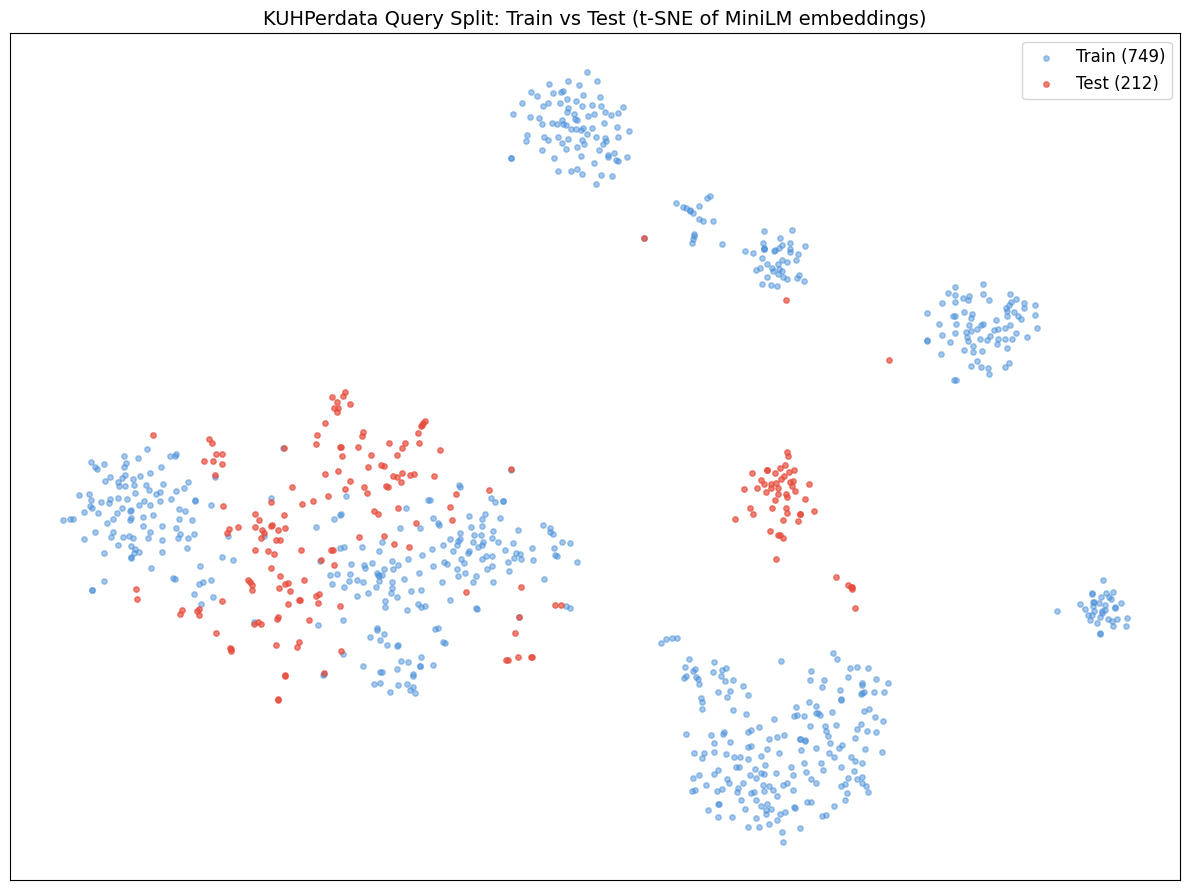

In [19]:
# Plot 1: Train vs Test split
fig, ax = plt.subplots(figsize=(12, 9))

train_mask = split_labels == "train"
test_mask = split_labels == "test"

ax.scatter(coords[train_mask, 0], coords[train_mask, 1],
           c="#4A90D9", s=15, alpha=0.5, label=f"Train ({train_mask.sum()})")
ax.scatter(coords[test_mask, 0], coords[test_mask, 1],
           c="#E74C3C", s=15, alpha=0.7, label=f"Test ({test_mask.sum()})")

ax.set_title("KUHPerdata Query Split: Train vs Test (t-SNE of MiniLM embeddings)", fontsize=14)
ax.legend(fontsize=12)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

C:\Users\ghana\AppData\Local\Temp\ipykernel_44868\908080420.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n_clusters)
C:\Users\ghana\AppData\Local\Temp\ipykernel_44868\908080420.py:11: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(coords[mask, 0], coords[mask, 1],
C:\Users\ghana\AppData\Local\Temp\ipykernel_44868\908080420.py:17: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter([], [], c="gray", marker="x", edgecolors="red", label="Test cluster")


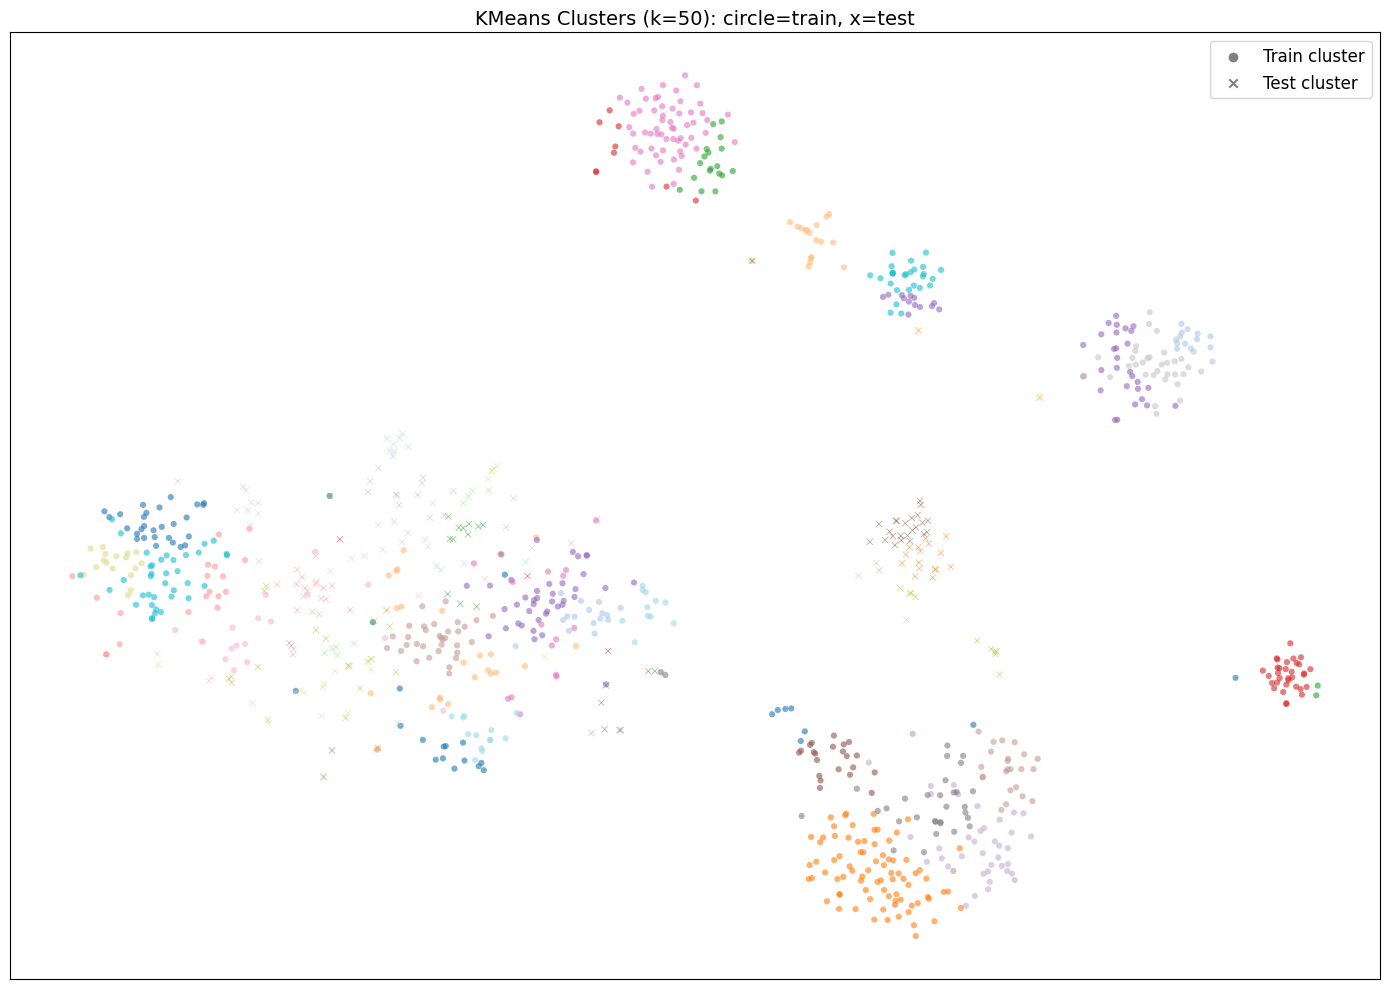

In [20]:
# Plot 2: Colored by cluster ID, marker by split
fig, ax = plt.subplots(figsize=(14, 10))

cmap = plt.cm.get_cmap("tab20", n_clusters)

for cid in range(n_clusters):
    mask = cluster_labels == cid
    is_test_cluster = cid in test_clusters
    marker = "x" if is_test_cluster else "o"
    edgecolor = "red" if is_test_cluster else "none"
    ax.scatter(coords[mask, 0], coords[mask, 1],
              c=[cmap(cid)] * mask.sum(), s=20, alpha=0.6,
              marker=marker, edgecolors=edgecolor, linewidths=0.5)

# Legend
ax.scatter([], [], c="gray", marker="o", label="Train cluster")
ax.scatter([], [], c="gray", marker="x", edgecolors="red", label="Test cluster")
ax.legend(fontsize=12)
ax.set_title(f"KMeans Clusters (k={n_clusters}): circle=train, x=test", fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

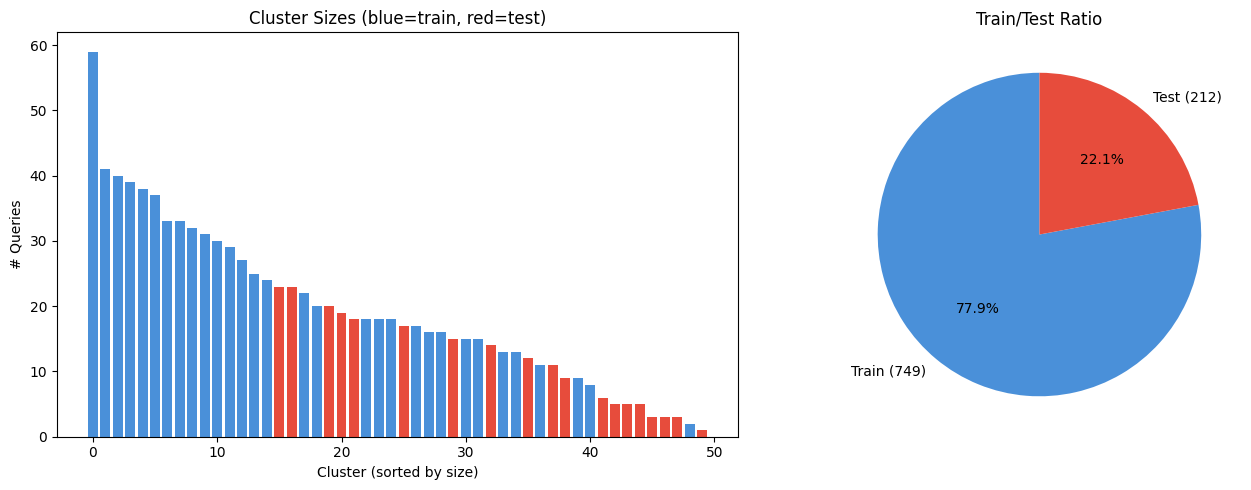

Mean intra-train cosine distance:  0.5030
Mean intra-test cosine distance:   0.5604
Mean train-test cosine distance:   0.5848
Separation ratio:                  1.1626x


In [21]:
# Plot 3: Cluster size distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: cluster sizes colored by split
cluster_sizes = []
colors = []
for cid in range(n_clusters):
    cluster_sizes.append((cluster_labels == cid).sum())
    colors.append("#E74C3C" if cid in test_clusters else "#4A90D9")

order = np.argsort(cluster_sizes)[::-1]
axes[0].bar(range(n_clusters), [cluster_sizes[i] for i in order],
            color=[colors[i] for i in order])
axes[0].set_xlabel("Cluster (sorted by size)")
axes[0].set_ylabel("# Queries")
axes[0].set_title("Cluster Sizes (blue=train, red=test)")

# Pie chart: train vs test
axes[1].pie([len(train_qids), len(test_qids)],
            labels=[f"Train ({len(train_qids)})", f"Test ({len(test_qids)})"],
            colors=["#4A90D9", "#E74C3C"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Train/Test Ratio")

plt.tight_layout()
plt.show()

# Print separation stats
si = stats["split_info"]
print(f"Mean intra-train cosine distance:  {si['mean_train_cosine_distance']:.4f}")
print(f"Mean intra-test cosine distance:   {si['mean_test_cosine_distance']:.4f}")
print(f"Mean train-test cosine distance:   {si['mean_train_test_cosine_distance']:.4f}")
print(f"Separation ratio:                  {si['separation_ratio']:.4f}x")